
# Сравнительный анализ моделей


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [150]:
runs = pd.read_csv("mlflow_runs_comparison.csv")


## 1. Подготовка данных

Мы выгрузили результаты из MLflow- в итоге получили: текстовые модели для Product, Issue и табличные MLP-модели.


In [165]:
runs["experiment_id"] = runs["experiment_id"].astype(float).astype(int).astype(str)
runs["target_group"] = runs["experiment_id"].map({
    "1": "Issue",
    "0": "Product",
    "2": "MLP"
})

In [169]:
runs.head()

,run_id,experiment_id,status,run_name,param_model_name,param_hidden_layers,param_activation,param_dropout,param_batch_size,param_learning_rate,...,param_vocab_size,param_model,param_vectorizer,param_max_features,param_stop_words,param_loss,param_ngram_range,param_test_size,param_random_state,target_group
0,ec38a00f90da4713b9f303fbd4ffa343,2,FINISHED,ResidualMLP,ResidualMLP,"[128, 128, 128]",ReLU,0.5,256.0,0.0005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MLP
1,42d78acae5c24895afa3cc217fb789f5,2,FINISHED,MLP_3_v2,MLP_3_v2,"[256, 128, 64]",ReLU,0.5,256.0,0.0005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MLP
2,872a279995ea4542aae7b316b9572eff,2,FINISHED,MLP_first_v3,MLP_first_v3,[64],ReLU,0.5,256.0,0.0005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MLP
3,4f7515e6cc2e4201967ea492796a69ca,2,FINISHED,MLP_first_v2,MLP_first_v2,[64],ReLU,0.3,256.0,0.0010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MLP
4,66d415b2a622443b9b963ed37f295ed3,2,FINISHED,MLP_3,MLP_3,"[256, 128, 64]",ReLU,0.3,256.0,0.0010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MLP


In [171]:
summary_counts = runs["target_group"].value_counts().reset_index()
summary_counts.columns = ["target_group", "n_runs"]
summary_counts


,target_group,n_runs
0,Product,12
1,Issue,11
2,MLP,7



## 2. Общий обзор количества запусков

Сначала посмотрим, сколько экспериментов было проведено для каждой части проекта.


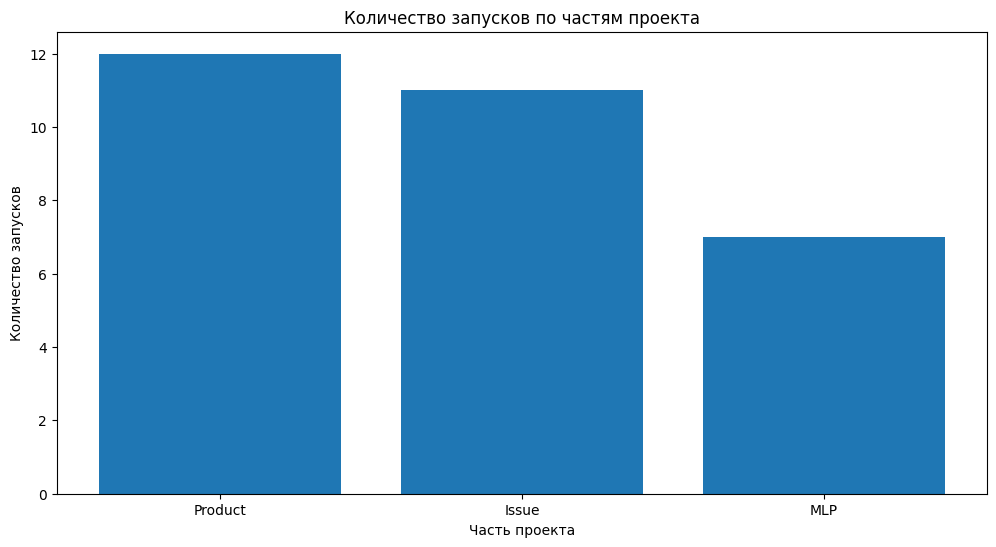

In [174]:
plt.figure(figsize=(12, 6))
plt.bar(summary_counts["target_group"], summary_counts["n_runs"])
plt.title("Количество запусков по частям проекта")
plt.xlabel("Часть проекта")
plt.ylabel("Количество запусков")
plt.show()


# 3. Сравнение моделей для Product



In [177]:
product_cols = [
    "run_name", "model_label",
    "metric_accuracy", "metric_precision_macro", "metric_recall_macro", "metric_f1_macro",
    "param_max_len", "param_learning_rate", "param_epochs",
    "param_ngram_range", "param_max_features"
]

product_table = product_runs[product_cols].sort_values(by=["metric_f1_macro", "metric_accuracy"],ascending=False)
product_table

,run_name,model_label,metric_accuracy,metric_precision_macro,metric_recall_macro,metric_f1_macro,param_max_len,param_learning_rate,param_epochs,param_ngram_range,param_max_features
15,DistilBERT,DistilBERT,0.874212,0.841373,0.833350,0.836957,200.0,0.00002,3.0,NaN,NaN
11,DistilBERT,DistilBERT,0.874675,0.837944,0.835185,0.836532,256.0,0.00003,4.0,NaN,NaN
7,DistilBERT,DistilBERT,0.870408,0.835961,0.831973,0.832156,256.0,0.00003,2.0,NaN,NaN
17,TextCNN,TextCNN,0.863636,0.839007,0.808745,0.822701,300.0,0.00100,8.0,NaN,NaN
16,TextCNN,TextCNN,0.865399,0.808112,0.842139,0.821767,300.0,0.00100,8.0,NaN,NaN
27,logreg_tfidf_bigrams,logreg_tfidf_bigrams,0.868089,0.833379,0.811447,0.821041,NaN,NaN,NaN,"(1,2)",5000.0
29,logreg_tfidf,logreg_tfidf,0.867904,0.835314,0.809752,0.821040,NaN,NaN,NaN,NaN,5000.0
24,LinearSVC,LinearSVC,0.861596,0.827876,0.808881,0.817530,NaN,NaN,NaN,NaN,5000.0
18,GRU,GRU,0.851948,0.807106,0.818395,0.811978,300.0,0.00100,8.0,NaN,NaN
20,LSTM,LSTM,0.855844,0.813008,0.805789,0.808999,400.0,0.00100,8.0,NaN,NaN



### 3.1. Accuracy по моделям Product

Accuracy для Product  хорошо отражает качество потому что классы достаточно различаются.


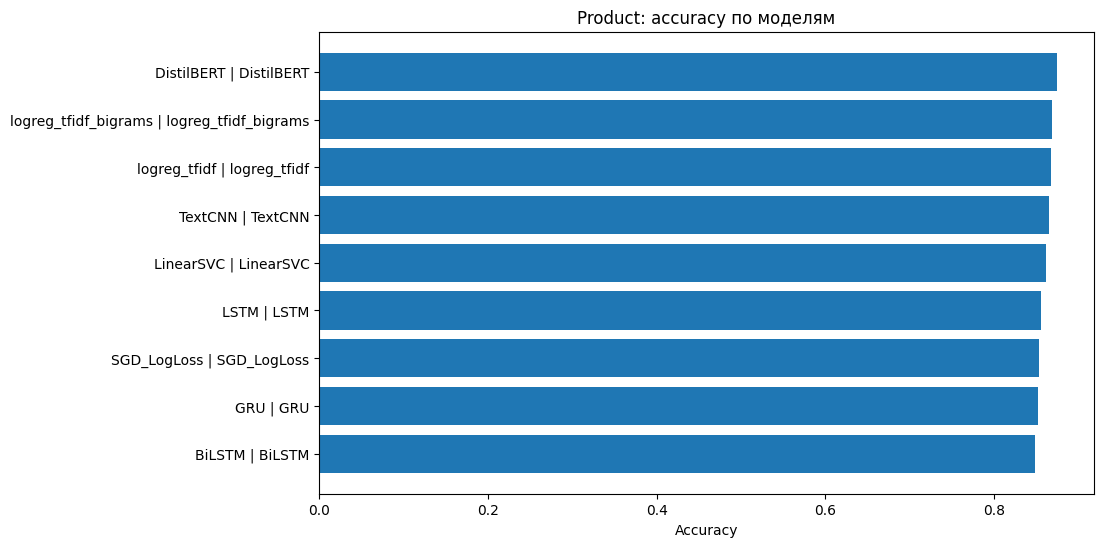

In [180]:
plot_df = product_table.copy()
plot_df["label"] = plot_df["run_name"] + " | " + plot_df["model_label"]
plot_df = plot_df.sort_values("metric_accuracy")
plt.figure(figsize=(10, 6))
plt.barh(plot_df["label"], plot_df["metric_accuracy"])
plt.title("Product: accuracy по моделям")
plt.xlabel("Accuracy")
plt.show()


### 3.2. Macro F1 по моделям Product

Macro F1 усредняет качество по классам и важен когда классы распределены неравномерно. Macro F1 показывает как хорошо модель работает не только на крупных классах но и на менее частых.


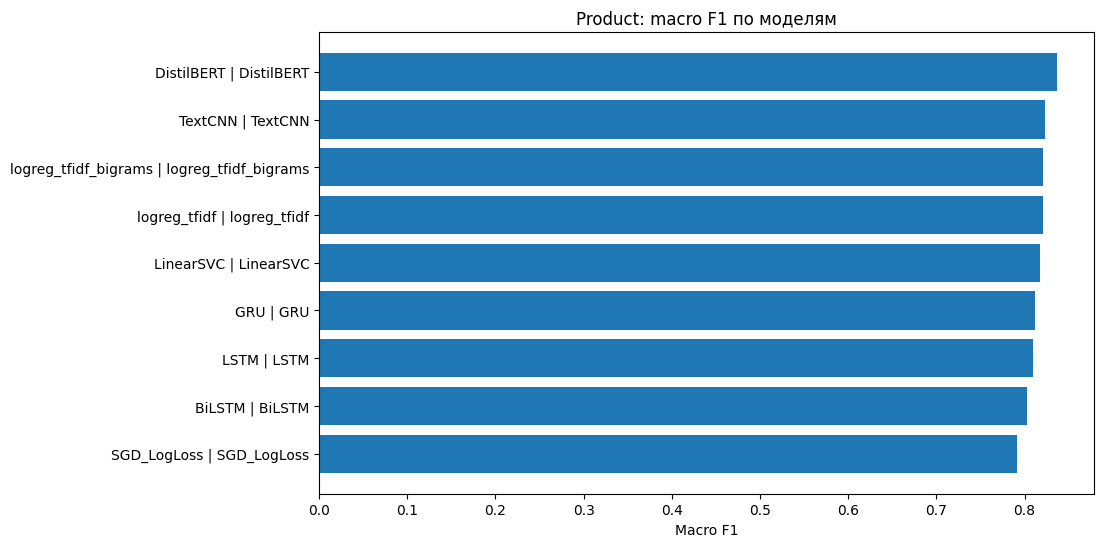

In [183]:
plot_df = product_table.copy()
plot_df["label"] = plot_df["run_name"] + " | " + plot_df["model_label"]
plot_df = plot_df.sort_values("metric_f1_macro")
plt.figure(figsize=(10, 6))
plt.barh(plot_df["label"], plot_df["metric_f1_macro"])
plt.title("Product: macro F1 по моделям")
plt.xlabel("Macro F1")
plt.show()



### Вывод по Product

Лучшее значение accuracy по Product показала модель DistilBERT / distilbert-base-uncased:

accuracy = 0.875
macro F1 = 0.837


Лучшей моделью для Product является DistilBERT - она показывает максимальное качество и лучше учитывает контекст жалобы. При этом TF-IDF + Logistic Regression и TextCNN также дают сильные результаты - это говорит нам о том что присутсвуют устойчивые ключевые слова и фразы в обращениях.


# 4. Сравнение моделей для Issue

Задача Issue получилась сложнее, чем у Product так как:

- классов больше
- некоторые классы смыслово близки
- класс Other неоднороден
- проблема может описываться длинной фразой, а не одним очевидным словом

Для Issue важно смотреть не только accuracy но и macro F1


In [187]:
issue_cols = [
    "run_name", "model_label",
    "metric_accuracy", "metric_precision_macro", "metric_recall_macro", "metric_f1_macro",
    "param_max_len", "param_learning_rate", "param_epochs",
    "param_ngram_range", "param_max_features"
]

issue_table = issue_runs[issue_cols].sort_values(by=["metric_f1_macro", "metric_accuracy"],ascending=False)
issue_table

,run_name,model_label,metric_accuracy,metric_precision_macro,metric_recall_macro,metric_f1_macro,param_max_len,param_learning_rate,param_epochs,param_ngram_range,param_max_features
10,TextCNN_3,TextCNN_3,0.643228,0.601911,0.670271,0.616977,300.0,0.00100,8.0,NaN,NaN
8,DistilBERT,DistilBERT,0.664657,0.611617,0.571796,0.583040,128.0,0.00002,2.0,NaN,NaN
9,DistilBERT,DistilBERT,0.664657,0.611617,0.571796,0.583040,128.0,0.00002,2.0,NaN,NaN
26,logreg_tfidf_bigram,logreg_tfidf_bigram,0.668182,0.653519,0.525119,0.568471,NaN,NaN,NaN,"(1,2)",5000.0
13,TextCNN,TextCNN,0.610761,0.543842,0.641204,0.567272,300.0,0.00100,8.0,NaN,NaN
28,logreg_tfidf,logreg_tfidf,0.665677,0.648765,0.520411,0.562985,NaN,NaN,NaN,NaN,5000.0
12,TextCNN_2,TextCNN_2,0.605009,0.536510,0.635151,0.560998,300.0,0.00100,8.0,NaN,NaN
23,LinearSVC,LinearSVC,0.652041,0.598300,0.527064,0.554006,NaN,NaN,NaN,NaN,5000.0
21,LinearSVC2,LinearSVC2,0.617532,0.522235,0.590411,0.547047,NaN,NaN,NaN,NaN,5000.0
14,LSTM,LSTM,0.634045,0.567065,0.500471,0.524333,300.0,0.00100,8.0,NaN,NaN



### 4.1. Accuracy по моделям Issue




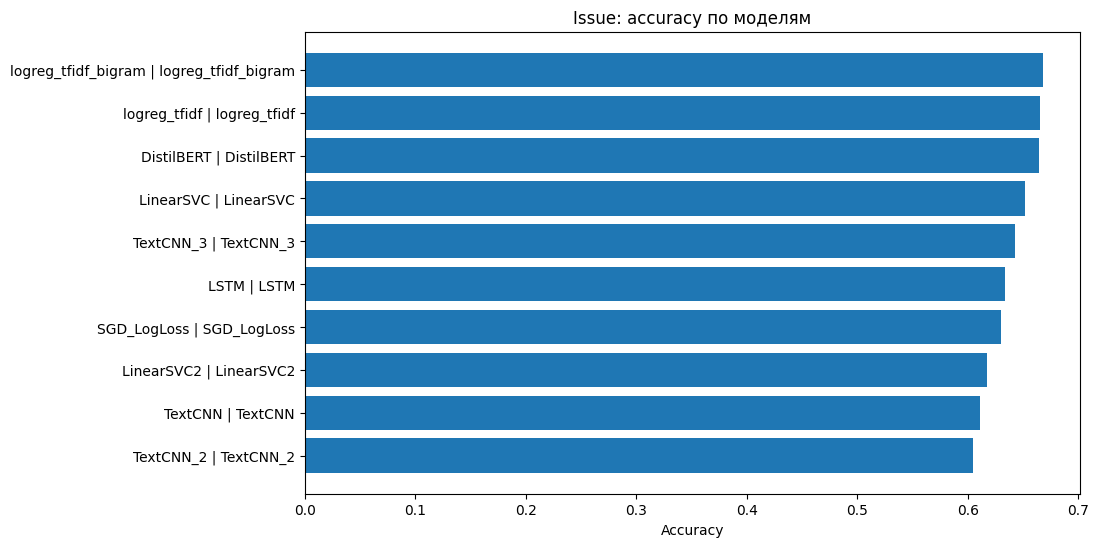

In [190]:
plot_df = issue_table.copy()
plot_df["label"] = plot_df["run_name"] + " | " + plot_df["model_label"]
plot_df = plot_df.sort_values("metric_accuracy")
plt.figure(figsize=(10, 6))
plt.barh(plot_df["label"], plot_df["metric_accuracy"])
plt.title("Issue: accuracy по моделям")
plt.xlabel("Accuracy")
plt.show()



### 4.2. Macro F1 по моделям Issue



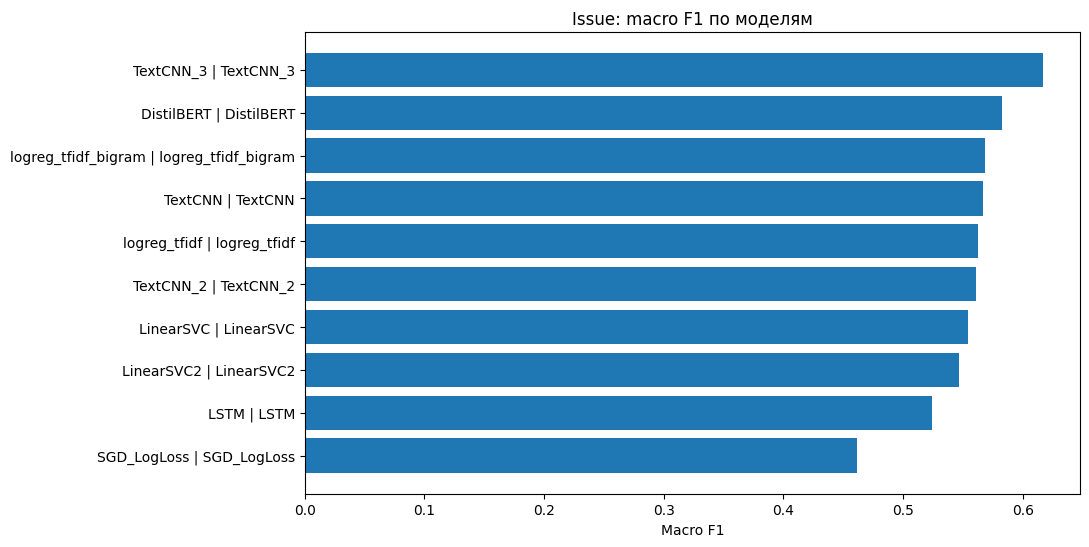

In [193]:
plot_df = issue_table.copy()
plot_df["label"] = plot_df["run_name"] + " | " + plot_df["model_label"]
plot_df = plot_df.sort_values("metric_f1_macro")
plt.figure(figsize=(10, 6))
plt.barh(plot_df["label"], plot_df["metric_f1_macro"])
plt.title("Issue: macro F1 по моделям")
plt.xlabel("Macro F1")
plt.show()



### Вывод по Issue

Лучшее значение accuracy по Issue показала модель logreg_tfidf_bigram / LogisticRegression:

- accuracy = 0.668
- macro F1 = 0.568

Лучшее значение macro F1 по Issue показала модель TextCNN_3 / ТextCNN_3:

- accuracy = 0.643
- macro F1 = 0.617

BERT мы выбрали как финальную NLP-модель для пайплайна - так как она хорошо подходит для обработки естественного языка и соблюдает единый подход для двух задач: Product и Issue.
Классические и CNN-модели использовались как сильные baseline-модели для сравнения



# 5. Сравнение табличных MLP-моделей

В табличной части мы  решаем задачу бинарной классификации high_risk. В неё передаются табличные признаки и предсказанные NLP-моделями категории

MLP не использует настоящие Product и Issue за признаки а работает с результатами предыдущего NLP-этапа.


In [197]:
tabular_cols = [
    "run_name", "model_label",
    "metric_accuracy", "metric_precision", "metric_recall", "metric_f1", "metric_roc_auc",
    "metric_train_loss", "metric_val_loss",
    "metric_train_acc", "metric_val_acc",
    "param_hidden_layers", "param_dropout", "param_learning_rate", "param_epochs"
]

tabular_table = tabular_runs[tabular_cols].sort_values(by=["metric_roc_auc", "metric_accuracy"],ascending=False)
tabular_table

,run_name,model_label,metric_accuracy,metric_precision,metric_recall,metric_f1,metric_roc_auc,metric_train_loss,metric_val_loss,metric_train_acc,metric_val_acc,param_hidden_layers,param_dropout,param_learning_rate,param_epochs
2,MLP_first_v3,MLP_first_v3,0.710575,0.399894,0.638748,0.491857,0.764606,0.855055,0.873618,0.703258,0.705195,[64],0.5,0.0005,15.0
1,MLP_3_v2,MLP_3_v2,0.702968,0.393709,0.656514,0.492230,0.763695,0.814305,0.880446,0.715003,0.700557,"[256, 128, 64]",0.5,0.0005,20.0
6,MLP_first,MLP_first,0.700093,0.389130,0.645093,0.485437,0.762523,0.838464,0.878571,0.712638,0.702783,[64],0.3,0.0010,30.0
3,MLP_first_v2,MLP_first_v2,0.691837,0.381962,0.655668,0.482716,0.761652,0.833300,0.884095,0.711655,0.697774,[64],0.3,0.0010,30.0
0,ResidualMLP,ResidualMLP,0.686364,0.378784,0.672166,0.484525,0.760514,0.766138,0.934149,0.725818,0.670686,"[128, 128, 128]",0.5,0.0005,20.0
5,MLP_second,MLP_second,0.651020,0.354919,0.723350,0.476190,0.756700,0.777791,0.909832,0.709928,0.654545,"[128, 64]",0.3,0.0010,30.0
4,MLP_3,MLP_3,0.678942,0.371214,0.668782,0.477427,0.754364,0.774403,0.918704,0.716385,0.679777,"[256, 128, 64]",0.3,0.0010,30.0



### 5.1. Accuracy и F1 по MLP-моделям




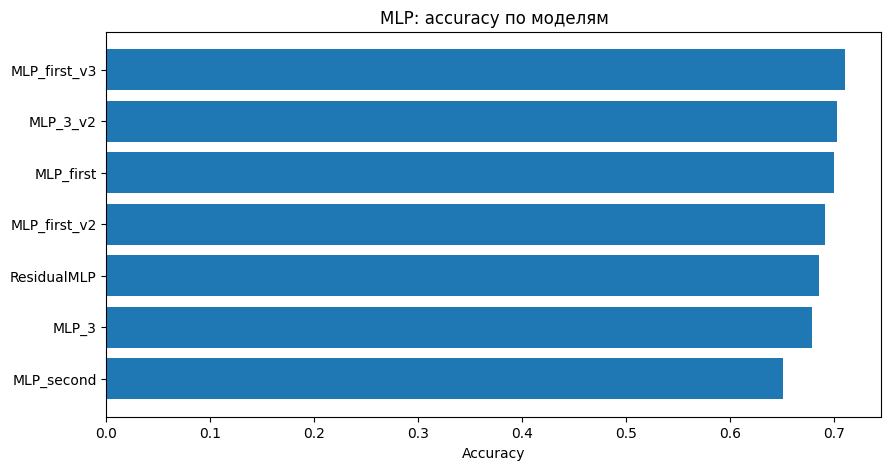

In [200]:
plot_df = tabular_table.copy()
plot_df["label"] = plot_df["run_name"]
plot_df = plot_df.sort_values("metric_accuracy")
plt.figure(figsize=(10, 5))
plt.barh(plot_df["label"], plot_df["metric_accuracy"])
plt.title("MLP: accuracy по моделям")
plt.xlabel("Accuracy")
plt.show()

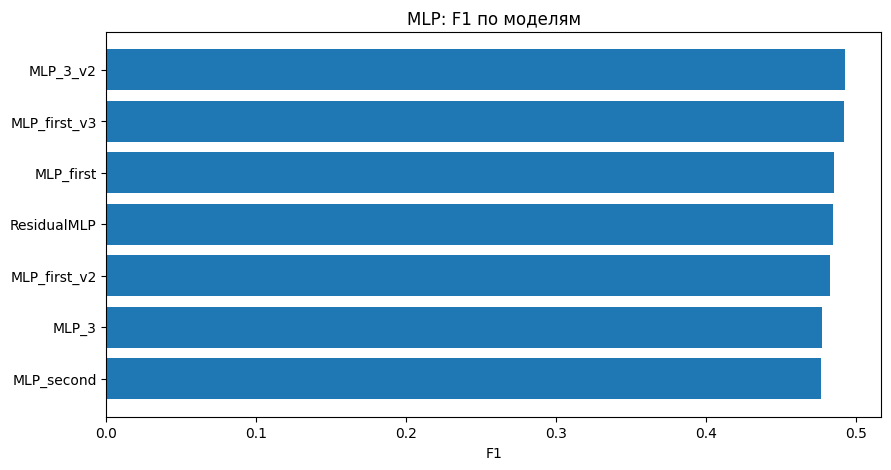

In [202]:
plot_df = tabular_table.copy()
plot_df["label"] = plot_df["run_name"]
plot_df = plot_df.sort_values("metric_f1")
plt.figure(figsize=(10, 5))
plt.barh(plot_df["label"], plot_df["metric_f1"])
plt.title("MLP: F1 по моделям")
plt.xlabel("F1")
plt.show()


### 5.2. ROC-AUC по MLP-моделям

ROC-AUC показывает как хорошо модель разделяет низкорисковые и высокорисковые обращения при разных порогах классификации - 
для бинарной задачи риска эта метрика важна


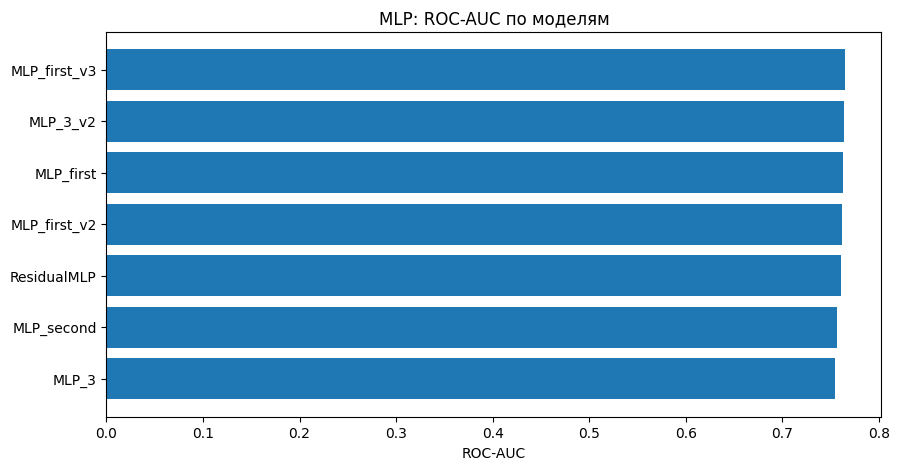

In [205]:
plot_df = tabular_table.copy()
plot_df["label"] = plot_df["run_name"]
plot_df = plot_df.sort_values("metric_roc_auc")
plt.figure(figsize=(10, 5))
plt.barh(plot_df["label"], plot_df["metric_roc_auc"])
plt.title("MLP: ROC-AUC по моделям")
plt.xlabel("ROC-AUC")
plt.show()


### Вывод по MLP

Лучшее значение accuracy среди табличных моделей показала MLP_first_v3 - 0.711

Лучшее значение ROC-AUC показала MLP_first_v3 - 0.765


Лучшее значение F1 показала MLP_3_v2 - 0.492

MLP_first_v3 выбрали как лучшую табличную модель , так как она показывает максимальную accuracy и один из лучших ROC-AUC. Более сложная ResidualMLP не дала прироста -  поэтому усложнение архитектуры в этой задаче оказалось нецелесообразным
